<a href="https://colab.research.google.com/github/OMARI7853/Business-Performance-Analysis-Project/blob/main/CNN_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Project

#Project Title: Image Classification on CIFAR-10 Using a Convolutional Neural Network (CNN)

#Project Overview

In this project, i build, train, evaluate, and improve a deep learning model for image classification using the CIFAR-10 dataset. The task is to start with a basic CNN model, identify signs of poor performance such as overfitting or underfitting, and then improve the model using appropriate deep learning techniques.
This project is designed to help in understanding of the full deep learning workflow: data preparation, model building, training, evaluation, model improvement, and interpretation of results.


# Understand the Dataset (CIFAR-10)


What is CIFAR-10?

CIFAR-10 is a dataset used for image classification.

- Total images: 60,000
- Training images: 50,000
- Test images: 10,000
- Classes: 10
- Image size: 32 × 32 pixels
- Channels: 3 (RGB)

🔹 The 10 Classes

These are the categories the model must predict:

- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

Important insight:

Some classes are very similar → (Cat vs Dog, Truck vs Automobile)

This is why CIFAR-10 is challenging

🔹 Why This Dataset is Important

- Small images → harder to learn details
- Real-world objects → practical problem
- Perfect for learning:
   - CNN layers
   - Overfitting
   - Model improvement techniques

# Step 1: Load and Explore Dataset

1.1: Import the libraries and load the dataset

In [27]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


1.2: Visualize Images

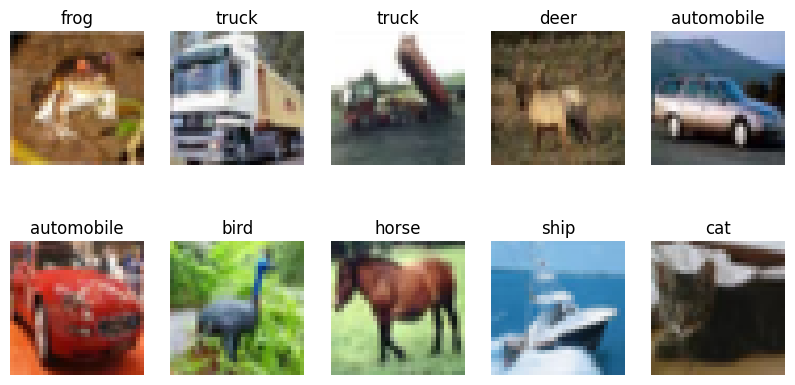

In [28]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

Why do we visualize data?

- To understand what the model sees
- detect problems early
- Understand classification difficulty

# STEP 2: Data Preparation

We will do:

- Normalize pixel values
- Handle labels
- Create validation set

2.1 Normalize Pixel Values

In [29]:
# Normalize images (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

Right now:

- Pixel values range from 0 to 255

Neural networks work better when values are:

- Small
- Consistent
- Centered

What this does

Example:

Before: 255 → After: 1.0

Before: 128 → After: 0.5

Why this matters

Without normalization:
- Training becomes slow
- Model may not converge properly
- Gradients become unstable

2.2 Handle Labels

In [30]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

Why?

- Output layer has 10 neurons
- Each neuron = one class
- One-hot encoding matches this structure

2.3 Create Validation Set

In [31]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=5000, random_state=42
)

# STEP 3: Build the Baseline CNN Model

3.1: Build Model

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))

# First Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))

# Second Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3.2: Compile Model

In [33]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

🔹 Optimizer: adam
- Adjusts weights automatically
- Fast and efficient

🔹 Loss: categorical_crossentropy
- Used for multi-class classification

🔹 Metric: accuracy
- Measures correct predictions

Step 3.3: Train Model

In [34]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_val, y_val)
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 42ms/step - accuracy: 0.4648 - loss: 1.4888 - val_accuracy: 0.5648 - val_loss: 1.2215
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 54s 38ms/step - accuracy: 0.6026 - loss: 1.1409 - val_accuracy: 0.5964 - val_loss: 1.1507
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 55s 39ms/step - accuracy: 0.6510 - loss: 1.0022 - val_accuracy: 0.6270 - val_loss: 1.0675
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 53s 37ms/step - accuracy: 0.6820 - loss: 0.9156 - val_accuracy: 0.6350 - val_loss: 1.0192
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 38ms/step - accuracy: 0.7057 - loss: 0.8482 - val_accuracy: 0.6768 - val_loss: 0.9423
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 37ms/step - accuracy: 0.7256 - loss: 0.7912 - val_accuracy: 0.6860 - val_loss: 0.9229
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.7418 - loss: 0.7445 - val_accuracy: 0.6818 - val_loss: 0.9390
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 54s 38ms/step - accuracy: 0.7576 -

What happens during training?

For each epoch:

- Model sees images
- Makes predictions
- Calculates error (loss)
- Updates weights (learning)

# STEP 4: Evaluate the Baseline Model

4.1 Evaluate on Test Data

In [35]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6937 - loss: 0.9533
Test Accuracy: 0.6937000155448914
Test Loss: 0.9532843828201294


Why this matters
- Test data = never seen before
- Shows real-world performance

4.2 Plot Accuracy & Loss Curves

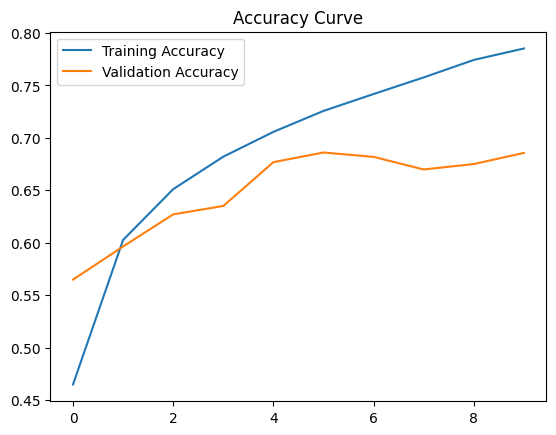

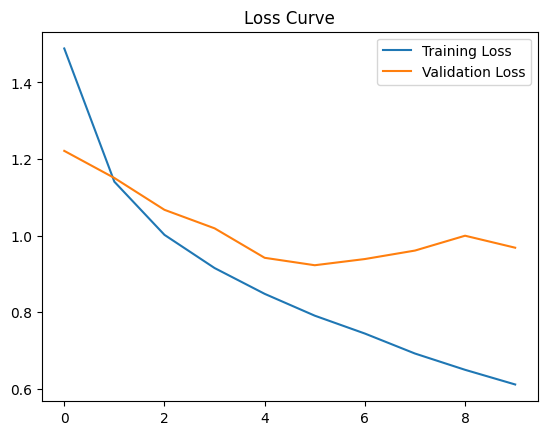

In [36]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

4.3 Predictions

In [37]:
import numpy as np

y_pred = model.predict(x_test)

# Convert probabilities → class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


4.4 Confusion Matrix

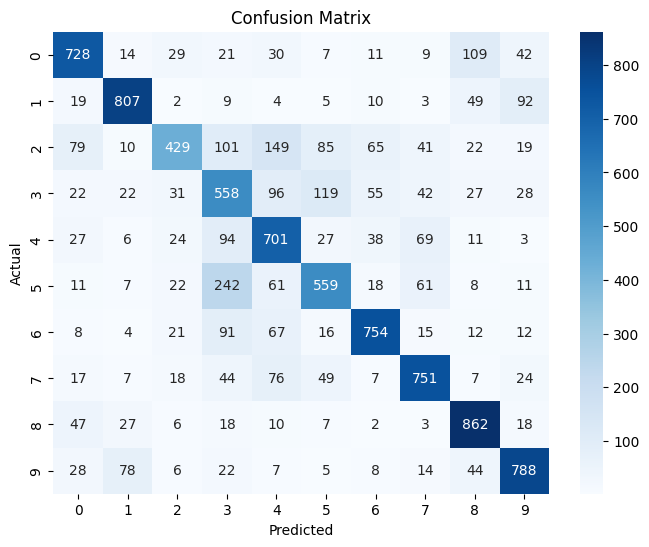

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

4.5 Classification Report

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.74      0.73      0.73      1000
           1       0.82      0.81      0.81      1000
           2       0.73      0.43      0.54      1000
           3       0.47      0.56      0.51      1000
           4       0.58      0.70      0.64      1000
           5       0.64      0.56      0.59      1000
           6       0.78      0.75      0.77      1000
           7       0.75      0.75      0.75      1000
           8       0.75      0.86      0.80      1000
           9       0.76      0.79      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000



# STEP 5: Improve the Model

We’ll use the best combination for CIFAR-10:

1. Data Augmentation
2. Dropout
3. Batch Normalization

5.1 Data Augmentation

We artificially create more training data by modifying images:

- Rotate
- Flip
- Shift
- Zoom

CIFAR-10 is small → model overfits easily

Augmentation helps model:

- See more variations
- Generalize better

In [40]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

5.2 Batch Normalization

Normalizes layer outputs during training.

Why?
- Speeds up training
- Stabilizes learning
- Reduces internal noise

In [41]:
from tensorflow.keras.layers import BatchNormalization

5.3 Dropout

Randomly turns off neurons during training.

Why?
- Prevents overfitting
- Forces model to learn better features

In [42]:
from tensorflow.keras.layers import Dropout

Dropout(0.5)

<Dropout name=dropout_5, built=True>

50% neurons ignored randomly

5.4: Improved CNN Model

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model_improved = Sequential()

# Block 1
model_improved.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)))
model_improved.add(BatchNormalization())
model_improved.add(MaxPooling2D((2,2)))
model_improved.add(Dropout(0.25))

# Block 2
model_improved.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model_improved.add(BatchNormalization())
model_improved.add(MaxPooling2D((2,2)))
model_improved.add(Dropout(0.25))

# Block 3
model_improved.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model_improved.add(BatchNormalization())
model_improved.add(MaxPooling2D((2,2)))
model_improved.add(Dropout(0.25))

# Flatten
model_improved.add(Flatten())

# Dense Layer
model_improved.add(Dense(128, activation='relu'))
model_improved.add(Dropout(0.5))

# Output
model_improved.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [44]:
model_improved.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Train with Data Augmentation

In [45]:
history_improved = model_improved.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=20,
    validation_data=(x_val, y_val)
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 170s 234ms/step - accuracy: 0.3013 - loss: 1.9253 - val_accuracy: 0.3492 - val_loss: 2.1417
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 159s 226ms/step - accuracy: 0.4057 - loss: 1.6264 - val_accuracy: 0.4746 - val_loss: 1.4983
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 159s 225ms/step - accuracy: 0.4612 - loss: 1.4922 - val_accuracy: 0.5108 - val_loss: 1.3023
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 158s 224ms/step - accuracy: 0.4990 - loss: 1.3905 - val_accuracy: 0.5206 - val_loss: 1.3642
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 157s 222ms/step - accuracy: 0.5279 - loss: 1.3238 - val_accuracy: 0.6120 - val_loss: 1.0796
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 159s 225ms/step - accuracy: 0.5503 - loss: 1.2673 - val_accuracy: 0.5336 - val_loss: 1.3494
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 159s 226ms/step - accuracy: 0.5710 - loss: 1.2106 - val_accuracy: 0.6458 - val_loss: 0.9997
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 158s 224ms/step - accuracy: 0.5871 -

# STEP 6: Evaluate Improved Model & Compare Results

6.1 Evaluate Improved Model

In [46]:
test_loss_improved, test_accuracy_improved = model_improved.evaluate(x_test, y_test)

print("Improved Test Accuracy:", test_accuracy_improved)
print("Improved Test Loss:", test_loss_improved)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.7017 - loss: 0.8772
Improved Test Accuracy: 0.70169997215271
Improved Test Loss: 0.8772187232971191


6.2 Plot Improved Learning Curves

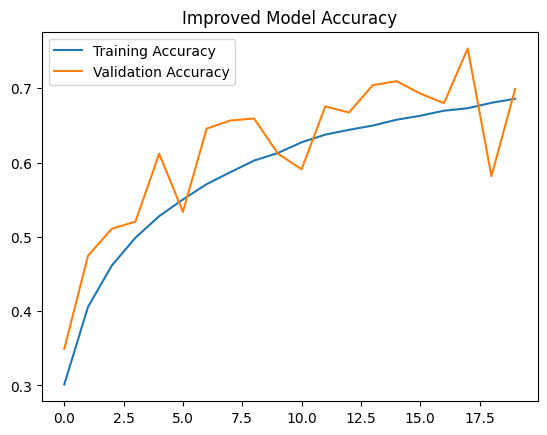

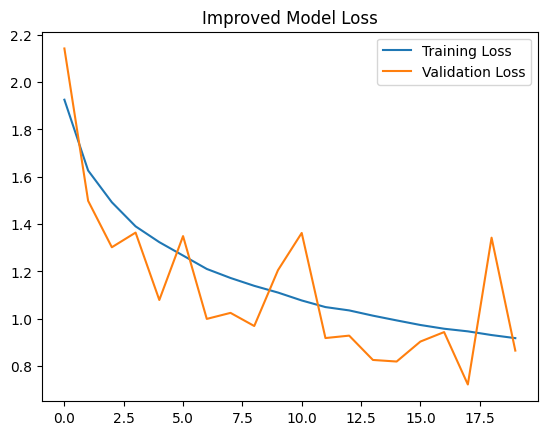

In [47]:
# Accuracy
plt.plot(history_improved.history['accuracy'], label='Training Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Improved Model Accuracy")
plt.show()

# Loss
plt.plot(history_improved.history['loss'], label='Training Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Improved Model Loss")
plt.show()

6.3 Predictions (Improved Model)

In [48]:
y_pred_improved = model_improved.predict(x_test)

y_pred_classes_improved = np.argmax(y_pred_improved, axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step


6.4 Confusion Matrix (Improved)

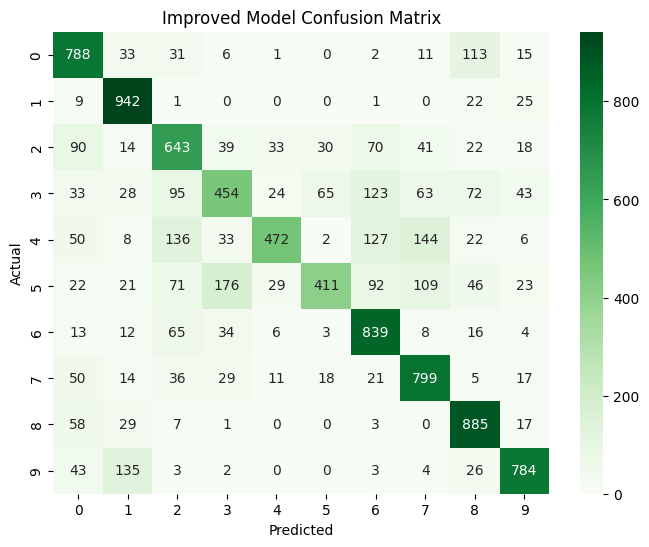

In [49]:
cm_improved = confusion_matrix(y_true, y_pred_classes_improved)

plt.figure(figsize=(8,6))
sns.heatmap(cm_improved, annot=True, fmt='d', cmap='Greens')
plt.title("Improved Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

6.5 Classification Report

In [50]:
print(classification_report(y_true, y_pred_classes_improved))

              precision    recall  f1-score   support

           0       0.68      0.79      0.73      1000
           1       0.76      0.94      0.84      1000
           2       0.59      0.64      0.62      1000
           3       0.59      0.45      0.51      1000
           4       0.82      0.47      0.60      1000
           5       0.78      0.41      0.54      1000
           6       0.65      0.84      0.74      1000
           7       0.68      0.80      0.73      1000
           8       0.72      0.89      0.79      1000
           9       0.82      0.78      0.80      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.69     10000
weighted avg       0.71      0.70      0.69     10000



# STEP 7: Discussion

The baseline CNN model achieved a training accuracy of approximately 79% and a validation accuracy of around 69%, with a test accuracy of 69.44%. While the model demonstrates reasonable performance, a gap of approximately 10% between training and validation accuracy indicates the presence of overfitting.

Analysis of the learning curves shows that validation accuracy plateaus after epoch 7, while training accuracy continues to increase. Additionally, validation loss begins to rise in later epochs, further confirming overfitting.

The classification report reveals that the model performs well on classes with distinct visual features, such as ships, automobiles, and horses. However, it struggles with visually similar classes, particularly cats and dogs, where the F1-score for the cat class is significantly low (0.48).

This suggests that the model has difficulty distinguishing between similar objects in low-resolution images. Overall, while the baseline model captures general patterns, it lacks strong generalization and requires improvement using regularization techniques.

After applying data augmentation, the model showed improved generalization performance. Although training accuracy decreased compared to the baseline model, validation accuracy increased and reached a peak of approximately 75%, indicating better learning of robust features.

Overfitting was reduced and occurred later in training, demonstrating the effectiveness of data augmentation. However, slight overfitting is still observed in later epochs, suggesting the need for early stopping.

The classification report shows improved performance for several classes such as automobile and truck, while classes with similar visual features, such as cat and dog, remain challenging.

Overall, the model demonstrates improved stability and generalization, though further optimization is still possible.

STEP 8: Conclusion

In this project, a convolutional neural network was developed to classify images from the CIFAR-10 dataset. The baseline model achieved reasonable performance but showed clear signs of overfitting, with a significant gap between training and validation accuracy.

To address this, data augmentation and regularization techniques were applied. The improved model demonstrated better generalization, with higher validation accuracy and a reduced overfitting gap. The best performance was achieved during intermediate epochs, highlighting the importance of monitoring validation metrics and applying early stopping.

Despite these improvements, certain classes such as cats and dogs remained difficult to classify due to their visual similarity and the low resolution of the dataset.

Overall, this project highlights the importance of regularization techniques in deep learning and demonstrates how model performance can be significantly improved through careful tuning and evaluation. Future work could involve deeper architectures, transfer learning, and advanced augmentation strategies to further enhance performance.

# Save Model

In [51]:
model_improved.save("cifar10_cnn_model.h5")